# Import Awattar prices from last year

API docu can be found here:
https://www.awattar.at/services/api

In [9]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# Define the API endpoint
api_endpoint = 'https://api.awattar.at/v1/marketdata'
# Set the date range for the last year
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

# Request data from the API
response = requests.get(api_endpoint, params={'start': start_date.isoformat(), 'end': end_date.isoformat()})

data = response.json()

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data['data'])

# Convert isoformat to day format
df['start_timestamp']= pd.to_datetime(df['start_timestamp'], unit='ms')
df['end_timestamp']= pd.to_datetime(df['end_timestamp'], unit='ms')

# Convert the DataFrame to a CSV file
df.to_csv('awattar_prices_last_year.csv', index=False)


<Axes: title={'center': 'awattar.at'}, xlabel='start_timestamp'>

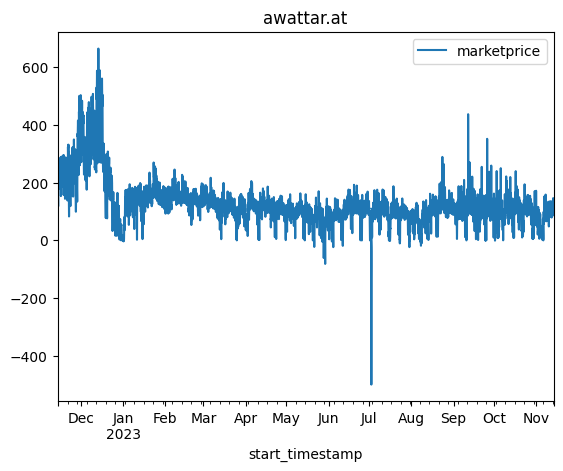

In [10]:
# plot the data
df.plot(x='start_timestamp', y='marketprice', title='awattar.at')

In [11]:
# extend the script to get data from .at and .de
import requests
import pandas as pd
from datetime import datetime, timedelta

dfs=[]

for country in ['at', 'de']:
    # Define the API endpoint
    api_endpoint = 'https://api.awattar.{}/v1/marketdata'.format(country)
    # Set the date range for the last year
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)

    # Request data from the API
    response = requests.get(api_endpoint, params={'start': start_date.isoformat(), 'end': end_date.isoformat()})

    data = response.json()

    # Convert the data to a pandas DataFrame
    df = pd.DataFrame(data['data'])
    df['country']=country

    dfs.append(df)

# Concatenate the DataFrames
df = pd.concat(dfs, ignore_index=True)

# Convert isoformat to day format
df['start_timestamp']= pd.to_datetime(df['start_timestamp'], unit='ms')
df['end_timestamp']= pd.to_datetime(df['end_timestamp'], unit='ms')

# Convert the DataFrame to a CSV file
df.to_csv('awattar_prices_last_year.csv', index=False)
